# 01. E-Cell4 はじめの一歩 — 可逆反応 A ⇌ B

E-Cell4 は細胞のような複雑・多階層な系をモデル化／シミュレーション／解析するための Python プラットフォーム。
この最初のノートでは、もっとも単純な可逆反応を **決定論的（ODE）** と **確率論的（Gillespie）** の 2 通りで解いて、両者の違いを体感する。

$$ A \underset{k_r}{\overset{k_f}{\rightleftharpoons}} B \qquad k_f = 0.25,\; k_r = 1.0 $$

平衡では正逆の速度が釣り合う: $k_f[A] = k_r[B]$。よって $[A]/[B] = k_r/k_f = 4$。
初期に $A=60,\,B=0$ なら、全 60 分子が $A:B = 48:12$ 付近に落ち着く。

In [1]:
import warnings
warnings.filterwarnings('ignore')  # ライブラリ内の軽微な SyntaxWarning を抑制

import ecell4
from ecell4 import get_model, reaction_rules, run_simulation
print('ecell4', ecell4.__version__)

ecell4 1.2.2


## モデルを定義する

`reaction_rules()` ブロックの中では E-Cell4 独自の DSL が使える。`A > B | k` が「A→B, 速度定数 k」を表す。
ブロックを抜けたあと `get_model()` でモデルオブジェクトを取り出す。

In [2]:
kf, kr = 0.25, 1.0

with reaction_rules():
    A > B | kf
    B > A | kr

model = get_model()
model

## 1) 決定論ソルバ（ODE）

`run_simulation` は結果を `Result` オブジェクトで返す。`.as_dataframe()` で pandas に、`.as_array()` で ndarray に変換できる。

In [3]:
y0 = {'A': 60, 'B': 0}

ret_ode = run_simulation(10.0, y0=y0, model=model, solver='ode',
                         ndiv=200, species_list=['A', 'B'])
df = ret_ode.as_dataframe()
df.head()

,t,A,B
0,0.00,60.000000,0.000000
1,0.05,59.272957,0.727043
2,0.10,58.589963,1.410037
3,0.15,57.948349,2.051651
4,0.20,57.345609,2.654391


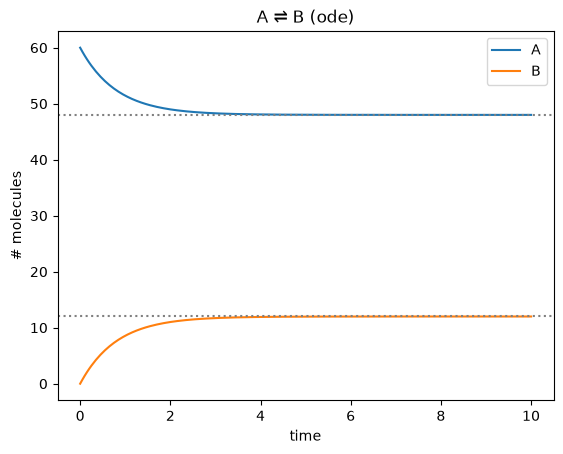

t=end -> [10.         48.00004472 11.99995528]


In [4]:
import matplotlib.pyplot as plt

arr = ret_ode.as_array()
t = arr[:, 0]
plt.plot(t, arr[:, 1], label='A')
plt.plot(t, arr[:, 2], label='B')
plt.axhline(48, ls=':', c='gray'); plt.axhline(12, ls=':', c='gray')
plt.xlabel('time'); plt.ylabel('# molecules'); plt.title('A ⇌ B (ode)')
plt.legend(); plt.show()
print('t=end ->', arr[-1])

## 2) 確率ソルバ（Gillespie）

同じモデル・同じ初期値で `solver='gillespie'` に変えるだけ。分子数が少ないので平衡値のまわりで揺らぐのが見える。
`rndseed` を固定すると再現性が得られる。

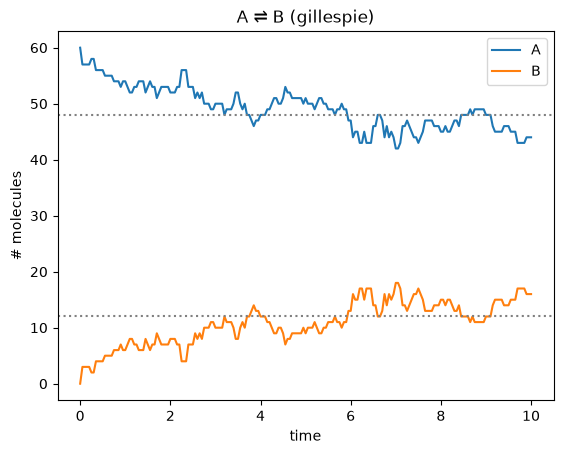

t=end -> [10. 44. 16.]


In [5]:
ret_g = run_simulation(10.0, y0=y0, model=model, solver='gillespie',
                       ndiv=200, species_list=['A', 'B'], rndseed=0)
arr = ret_g.as_array()
t = arr[:, 0]
plt.plot(t, arr[:, 1], label='A')
plt.plot(t, arr[:, 2], label='B')
plt.axhline(48, ls=':', c='gray'); plt.axhline(12, ls=':', c='gray')
plt.xlabel('time'); plt.ylabel('# molecules'); plt.title('A ⇌ B (gillespie)')
plt.legend(); plt.show()
print('t=end ->', arr[-1])

## 発展課題（自作）

1. `kf`, `kr` を変えて平衡比 $[A]/[B] = k_r/k_f$ が理論どおりか確かめる。
2. 初期分子数を `{'A': 6, 'B': 0}` のように小さくすると、Gillespie の揺らぎ（相対ノイズ）はどう変わる？
3. `solver='meso'` や `solver='ode'` 以外のソルバを試し、結果を比べる。
4. 反応を $A + B \to C$ のような 2 分子反応に変えてみる（`A + B > C | k`）。